## Classification – Bank Notes Workshop

### Overview
In this workshop, we train a neural network to classify a given banknote as either Genuine
or Counterfeit.

### Data
The dataset provided is called ‘banknotes.csv’ and consists of physical dimensions of
genuine and counterfeit Swiss banknotes. There are 200 samples in the dataset; 100 are
samples of Genuine banknotes and 100 are samples of Counterfeit banknotes. Source of
dataset - http:// www.statistics4u.com/fundstat_eng/data_fluriedw.html

In [26]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

1. Use Pandas to read in ‘banknotes.csv’

In [8]:
bn = pd.read_csv('banknotes.csv')
print(bn)

    Sample  Length   Left  Right  Bottom   Top  Diagonal  Genuine
0      BN1   214.8  131.0  131.1     9.0   9.7     141.0        1
1      BN2   214.6  129.7  129.7     8.1   9.5     141.7        1
2      BN3   214.8  129.7  129.7     8.7   9.6     142.2        1
3      BN4   214.8  129.7  129.6     7.5  10.4     142.0        1
4      BN5   215.0  129.6  129.7    10.4   7.7     141.8        1
..     ...     ...    ...    ...     ...   ...       ...      ...
195  BN196   215.0  130.4  130.3     9.9  12.1     139.6        0
196  BN197   215.1  130.3  129.9    10.3  11.5     139.7        0
197  BN198   214.8  130.3  130.4    10.6  11.1     140.0        0
198  BN199   214.7  130.7  130.8    11.2  11.2     139.4        0
199  BN200   214.3  129.9  129.9    10.2  11.5     139.6        0

[200 rows x 8 columns]


2. Use the following columns as features:
• Length
• Left
• Right
• Bottom
• Top
• Diagonal

3. Use the column ‘Genuine’ as your label, where a value of 0 denotes a Counterfeit
sample, and a value of 1 denotes a Genuine sample.
For example, with reference to the snapshot below, the sample BN100 denotes a
Genuine banknote, while BN101 denotes a Counterfeit banknote.


4. Out of the 200 samples, use only 90 Genuine and 90 Counterfeit samples for training. In
other words, your training features consists of 180 rows of data (half are Genuine, the
other half Counterfeit). Naturally, your training labels would then come from the
selected 180 rows of data.
The remaining 20 samples (10 Genuine; 10 Counterfeit) is for testing the accuracy of
your neural network.

In [19]:
# Test train data
X = bn.drop(columns=[ 'Sample', 'Genuine' ]).copy()
y = bn['Genuine'].copy()

# Split; stratify = y splits genuine / counterfeit evenly
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = .10,
    random_state = 42,
    stratify = y
)

print(y_train[y_train == 0].size, y_train[y_train == 1].size)
print(y_test[y_test == 0].size, y_test[y_test == 1].size)

90 90
10 10


In [27]:
# Standardise data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Construct your neural network model and train it with 180 training samples. Then
evaluate its accuracy with the remaining 20 test samples.

In [28]:
# Build neural network
model = keras.Sequential([
    keras.Input(shape = (6,)),
    layers.Dense(16, activation = "relu"),
    layers.Dense(8, activation = "relu"),
    layers.Dense(1, activation = "sigmoid")
])

# Compile model
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [30]:
# Train model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 500,
    validation_data = (X_test_scaled, y_test),
    verbose = 1
)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3889 - loss: 0.7152 - val_accuracy: 0.7000 - val_loss: 0.6331
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6778 - loss: 0.6145 - val_accuracy: 0.8500 - val_loss: 0.5124
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8667 - loss: 0.4991 - val_accuracy: 0.9500 - val_loss: 0.4007
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9278 - loss: 0.3904 - val_accuracy: 0.9500 - val_loss: 0.3059
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9500 - loss: 0.3023 - val_accuracy: 0.9500 - val_loss: 0.2283
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9611 - loss: 0.2320 - val_accuracy: 1.0000 - val_loss: 0.1702
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9778 - loss: 0.1793 - val_accuracy: 1.0000 - val_loss: 0.1263
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9833 - loss: 0.1368 - val_accuracy: 1.0000 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 5.4696e-06
Test loss: 5.469605639518704e-06
Test Accuracy: 1.0


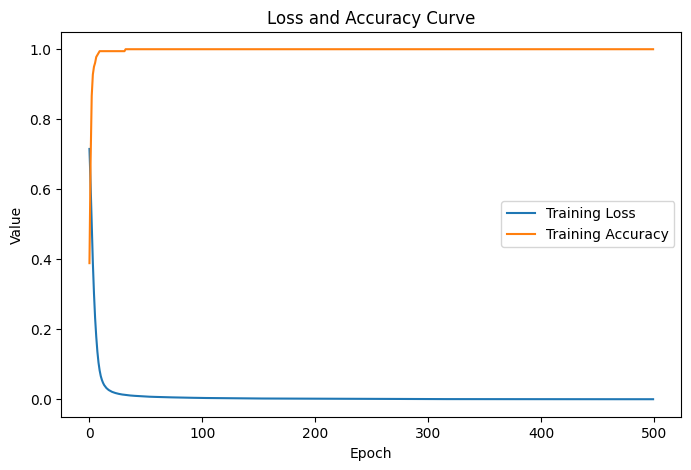

In [32]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("Test loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Plot training loss and accuracy
plt.figure(figsize = (8, 5))

plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Loss and Accuracy Curve")
plt.legend()
plt.show()

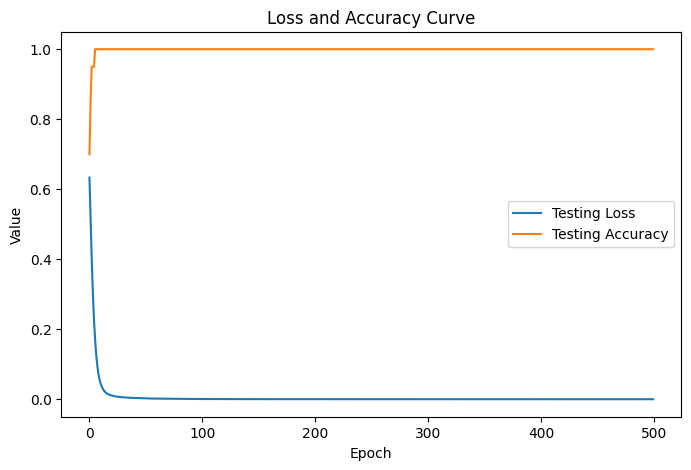

In [33]:
# Plot testing loss and accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"], label="Testing Loss")
plt.plot(history.history["val_accuracy"], label="Testing Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Loss and Accuracy Curve")

plt.legend()

plt.show()